In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, root_mean_squared_error
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from pathlib import Path




In [2]:
# Load the Kaggle Stroke Dataset
data_path = "healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)

# Display the first 5 rows and dataset summary
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()


Dataset Shape: (5110, 12)

First 5 rows of the dataset:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Display dataset summary
print("\nDataset Summary:")
print(df.info())


Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB
None


In [4]:
# Drop the 'id' column as it carries no predictive value
df_clean = df.drop(columns=['id'])

# Drop initial missing values to obtain a fully intact baseline dataset
df_clean = df_clean.dropna().reset_index(drop=True)

# Encode categorical features into numerical representations
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Display cleaned dataset information
print("Clean Dataset Shape:", df_clean.shape)
print("\nData Types and Missing Values Count:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows of Clean Dataset:")
df_clean.head()

Clean Dataset Shape: (4909, 11)

Data Types and Missing Values Count:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

First 5 rows of Clean Dataset:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2,1
2,0,49.0,0,0,1,2,1,171.23,34.4,3,1
3,0,79.0,1,0,1,3,0,174.12,24.0,2,1
4,1,81.0,0,0,1,2,1,186.21,29.0,1,1


In [5]:
# Separate features (X) and target label (y)
X = df_clean.drop(columns=["stroke"])
y = df_clean["stroke"]

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the Baseline Random Forest Classifier
# Handle class imbalance using class_weight='balanced'
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
baseline_rf.fit(X_train, y_train)

# Predict on the test set and calculate metrics
y_pred_baseline = baseline_rf.predict(X_test)

f1_baseline = f1_score(y_test, y_pred_baseline)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)

print("--- Baseline Model Performance (Clean Data) ---")
print(f"Accuracy : {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall   : {recall_baseline:.4f}")
print(f"F1 Score : {f1_baseline:.4f}")

--- Baseline Model Performance (Clean Data) ---
Accuracy : 0.8676
Precision: 0.1271
Recall   : 0.3571
F1 Score : 0.1875


In [6]:

def generate_missing_test_sets(X_test, rates=(0.10, 0.20, 0.30), random_state=42):
    """
    Add missing values to the test set at different rates.
    Missing values from lower rates are kept at higher rates.
    """
    rng = np.random.default_rng(random_state)
    random_values = rng.random(X_test.shape)

    missing_sets = {}
    masks = {}

    for rate in rates:
        label = f"{int(rate * 100)}%"
        mask = random_values < rate

        X_missing = X_test.mask(mask)

        missing_sets[label] = X_missing
        masks[label] = mask

    return missing_sets, masks


missing_rates = [0.10, 0.20, 0.30]

test_missing_sets, test_masks = generate_missing_test_sets(
    X_test, rates=missing_rates, random_state=42
)

print("--- Missing Data Summary ---")

for rate, X_missing in test_missing_sets.items():
    missing_count = X_missing.isna().sum().sum()
    missing_percent = missing_count / X_missing.size * 100

    print(f"{rate}: {missing_count} missing values ({missing_percent:.2f}%)")


--- Missing Data Summary ---
10%: 964 missing values (9.82%)
20%: 1996 missing values (20.33%)
30%: 2985 missing values (30.40%)


In [7]:

NUM_COLS = ["age", "avg_glucose_level", "bmi"]
CAT_COLS = [col for col in X_test.columns if col not in NUM_COLS]



def check_input(X):
    """Validate the input dataset."""
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    expected = NUM_COLS + CAT_COLS

    if set(X.columns) != set(expected):
        raise ValueError("The input has unexpected columns.")

    if X.columns.duplicated().any():
        raise ValueError("Duplicate columns are not allowed.")

    if not X.index.is_unique:
        raise ValueError("The index must be unique.")

    if X.empty:
        raise ValueError("The input dataset is empty.")

    if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
        raise TypeError("All features must be numerically encoded.")

    if np.isinf(X.to_numpy(dtype=float)).any():
        raise ValueError("Infinite values are not supported.")

    for col in X.columns:
        if X[col].isna().all():
            raise ValueError(f"All values are missing in '{col}'.")


def initial_fill(X):
    """Initialize missing values using medians and modes."""
    result = X.copy()

    for col in X.columns:
        observed = X[col].dropna()

        if col in NUM_COLS:
            fill_value = observed.median()
        else:
            fill_value = observed.mode().iloc[0]

        result[col] = result[col].fillna(fill_value)

    return result


def prepare_predictors(X_observed, X_missing):
    """Encode categorical predictors and scale numerical predictors."""
    numeric_cols = [
        col for col in X_observed.columns if col in NUM_COLS
    ]
    categorical_cols = [
        col for col in X_observed.columns if col in CAT_COLS
    ]

    transformers = []

    if numeric_cols:
        transformers.append(
            ("numeric", StandardScaler(), numeric_cols)
        )

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    X_observed_encoded = preprocessor.fit_transform(X_observed)
    X_missing_encoded = preprocessor.transform(X_missing)

    return X_observed_encoded, X_missing_encoded

def calculate_imputation_change(old_result, new_result, missing):
    """Measure changes between two MissForest iterations."""

    # Calculate changes in numerical features
    old_num = old_result[NUM_COLS].to_numpy(dtype=float)
    new_num = new_result[NUM_COLS].to_numpy(dtype=float)

    numeric_difference = np.sum((new_num - old_num) ** 2)
    numeric_denominator = np.sum(new_num ** 2)

    numeric_change = (
        numeric_difference / numeric_denominator
        if numeric_denominator > 0
        else 0.0
    )

    # Calculate changes in categorical features
    old_cat = old_result[CAT_COLS].to_numpy()
    new_cat = new_result[CAT_COLS].to_numpy()

    categorical_changes = np.sum(old_cat != new_cat)
    categorical_count = new_cat.size

    categorical_change = (
        categorical_changes / categorical_count
        if categorical_count > 0
        else 0.0
    )

    return numeric_change, categorical_change



In [8]:
class MixedKNNImputer:
    """Impute mixed-type data using observed-feature KNN distances."""

    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit_transform(self, X):
        check_input(X)

        if not isinstance(self.n_neighbors, int) or self.n_neighbors < 1:
            raise ValueError("n_neighbors must be at least 1.")

        result = X.copy()
        scale = X[NUM_COLS].std().replace(0, 1).fillna(1)

        for idx in X.index:
            row = X.loc[idx]
            missing_cols = row.index[row.isna()]
            observed_cols = row.index[row.notna()]

            for target in missing_cols:
                candidates = X.loc[X[target].notna()]

                if len(observed_cols) == 0:
                    neighbors = candidates[target]
                else:
                    distances = pd.Series(
                        0.0, index=candidates.index
                    )
                    counts = pd.Series(
                        0.0, index=candidates.index
                    )

                    for col in observed_cols:
                        valid = candidates[col].notna()

                        if col in NUM_COLS:
                            difference = (
                                (candidates[col] - row[col])
                                / scale[col]
                            ) ** 2
                        else:
                            difference = (
                                candidates[col] != row[col]
                            ).astype(float)

                        distances += difference.where(valid, 0)
                        counts += valid.astype(float)

                    distances = (
                        distances / counts.replace(0, np.nan)
                    ).dropna()

                    if distances.empty:
                        neighbors = candidates[target]
                    else:
                        neighbor_indices = distances.nsmallest(
                            self.n_neighbors
                        ).index

                        neighbors = candidates.loc[
                            neighbor_indices, target
                        ]

                if target in NUM_COLS:
                    value = neighbors.mean()
                else:
                    value = neighbors.mode().iloc[0]

                result.at[idx, target] = value

        return result
    


In [9]:
# Test the MixedKNNImputer using the 10% missing test dataset
X_missing = test_missing_sets["10%"].copy()

knn_imputer = MixedKNNImputer(n_neighbors=5)
X_imputed = knn_imputer.fit_transform(X_missing)

# Check the number of missing values
print("Missing values before imputation:")
print(X_missing.isna().sum())

print("\nMissing values after imputation:")
print(X_imputed.isna().sum())

# Display the first five rows
print("\nImputed dataset:")
print(X_imputed.head())


# Check whether all missing values have been filled
assert not X_imputed.isna().any().any()

# Check whether observed values remain unchanged
observed_mask = X_missing.notna()

assert np.array_equal(
    X_missing.to_numpy()[observed_mask.to_numpy()],
    X_imputed.to_numpy()[observed_mask.to_numpy()]
)

# Check whether categorical values remain valid
for col in CAT_COLS:
    valid_values = set(X_test[col].unique())
    imputed_values = set(X_imputed[col].unique())

    assert imputed_values.issubset(valid_values), (
        f"Invalid values found in {col}"
    )

print("All KNN validation tests passed.")


Missing values before imputation:
gender               102
age                   99
hypertension          96
heart_disease         89
ever_married         104
work_type            108
Residence_type        83
avg_glucose_level     95
bmi                   88
smoking_status       100
dtype: int64

Missing values after imputation:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64

Imputed dataset:
      gender   age  hypertension  heart_disease  ever_married  work_type  \
3845     1.0   9.0           0.0            0.0           0.0        4.0   
2061     0.0  77.0           0.0            0.0           1.0        2.0   
2691     0.0  50.0           0.0            0.0           1.0        2.0   
4568     1.0  46.0           0.0            0.0           1.0        2.0   
1363     1.0  53.0          

In [10]:
# Evaluate KNN imputation at 10%, 20%, and 30% missingness

knn_results = []

for rate in ["10%", "20%", "30%"]:

    # Get the incomplete test dataset
    X_missing = test_missing_sets[rate].copy()

    # Apply KNN imputation
    knn_imputer = MixedKNNImputer(n_neighbors=5)
    X_imputed = knn_imputer.fit_transform(X_missing)

    # Identify artificially missing values
    missing_mask = X_missing.isna()

    # Calculate numerical imputation errors
    num_mask = missing_mask[NUM_COLS].to_numpy()

    true_num = X_test[NUM_COLS].to_numpy()[num_mask]
    imputed_num = X_imputed[NUM_COLS].to_numpy()[num_mask]

    mae = mean_absolute_error(true_num, imputed_num)
    rmse = root_mean_squared_error(true_num, imputed_num)

    # Calculate categorical imputation accuracy
    cat_mask = missing_mask[CAT_COLS].to_numpy()

    true_cat = X_test[CAT_COLS].to_numpy()[cat_mask]
    imputed_cat = X_imputed[CAT_COLS].to_numpy()[cat_mask]

    cat_accuracy = np.mean(true_cat == imputed_cat)

    # Evaluate the existing Random Forest classifier
    y_pred = baseline_rf.predict(X_imputed)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Calculate the robustness score
    rq = f1 / f1_baseline if f1_baseline > 0 else np.nan

    # Save the results
    knn_results.append({
        "Missing Rate": rate,
        "MAE": mae,
        "RMSE": rmse,
        "Categorical Accuracy": cat_accuracy,
        "F1-score": f1,
        "Rq": rq
    })

# Display all results in one table
df_knn_results = pd.DataFrame(knn_results)

print("--- KNN Imputation and Robustness Results ---")
print(df_knn_results.to_string(index=False, float_format="%.4f"))


--- KNN Imputation and Robustness Results ---
Missing Rate     MAE    RMSE  Categorical Accuracy  F1-score     Rq
         10% 14.9744 26.2287                0.7082    0.1829 0.9756
         20% 16.9926 27.8392                0.6551    0.1517 0.8092
         30% 18.0521 29.2241                0.6651    0.1333 0.7111


In [11]:
class MixedMICEImputer:
    """Stochastic chained-equations imputation for mixed-type data."""

    def __init__(
        self,
        max_iter=10,
        random_state=42
    ):
        self.max_iter = max_iter
        self.random_state = random_state

    def fit_transform(self, X):
        check_input(X)

        rng = np.random.default_rng(self.random_state)
        missing = X.isna()
        result = initial_fill(X)

        target_cols = [
            col for col in X.columns if missing[col].any()
        ]

        for iteration in range(self.max_iter):
            for col in target_cols:
                observed_rows = ~missing[col]
                missing_rows = missing[col]

                predictors = result.drop(columns=col)

                X_observed = predictors.loc[observed_rows]
                X_missing = predictors.loc[missing_rows]

                y_observed = X.loc[observed_rows, col]

                X_observed, X_missing = prepare_predictors(
                    X_observed,
                    X_missing
                )

                if col in NUM_COLS:
                    model = BayesianRidge()
                    model.fit(X_observed, y_observed)

                    mean, std = model.predict(
                        X_missing,
                        return_std=True
                    )

                    predictions = rng.normal(mean, std)
                    
                    # Keep imputed values within the observed range
                    predictions = np.clip(
                        predictions,
                        y_observed.min(),
                        y_observed.max()
                    )
                else:
                    if y_observed.nunique() == 1:
                        predictions = np.repeat(
                            y_observed.iloc[0],
                            missing_rows.sum()
                        )
                    else:
                        model = LogisticRegression(
                            max_iter=2000
                        )

                        model.fit(X_observed, y_observed)

                        probabilities = model.predict_proba(
                            X_missing
                        )

                        predictions = [
                            rng.choice(
                                model.classes_,
                                p=probabilities[i]
                            )
                            for i in range(len(probabilities))
                        ]

                result.loc[missing_rows, col] = predictions

        return result
    
    
    def multiple_impute(self, X, n_imputations=5):
        """Generate multiple stochastic imputed datasets."""
        imputed_datasets = []

        for i in range(n_imputations):
            imputer = MixedMICEImputer(
                max_iter=self.max_iter,
                random_state=self.random_state + i
            )

            X_imputed = imputer.fit_transform(X.copy())
            imputed_datasets.append(X_imputed)

        return imputed_datasets



In [12]:
# Test MICE using the 10% missing dataset
X_missing = test_missing_sets["10%"].copy()

mice_imputer = MixedMICEImputer(
    max_iter=10,
    random_state=42
)

mice_imputations = mice_imputer.multiple_impute(
    X_missing,
    n_imputations=5
)

print(f"Generated {len(mice_imputations)} MICE datasets.")

for i, X_imputed in enumerate(mice_imputations, start=1):
    print(
        f"Imputation {i}: "
        f"{X_imputed.isna().sum().sum()} missing values remaining"
    )
    

# Validate all five imputed datasets
assert len(mice_imputations) == 5

observed_mask = X_missing.notna()

for i, X_imputed in enumerate(mice_imputations, start=1):
    assert X_imputed.shape == X_test.shape
    assert X_imputed.columns.equals(X_test.columns)
    assert X_imputed.index.equals(X_test.index)

    assert not X_imputed.isna().any().any(), (
        f"Imputation {i} still contains missing values."
    )

    assert np.array_equal(
        X_missing.to_numpy()[observed_mask.to_numpy()],
        X_imputed.to_numpy()[observed_mask.to_numpy()]
    ), f"Imputation {i} modified observed values."

    for col in CAT_COLS:
        valid_values = set(X_test[col].dropna().unique())
        imputed_values = set(X_imputed[col].dropna().unique())

        assert imputed_values.issubset(valid_values), (
            f"Imputation {i} contains invalid values in {col}."
        )

    negative_counts = (X_imputed[NUM_COLS] < 0).sum()

    print(f"\nImputation {i}:")
    print("Missing values:", X_imputed.isna().sum().sum())
    print("Negative numerical values:")
    print(negative_counts)

    assert not (X_imputed[NUM_COLS] < 0).any().any(), (
        f"Imputation {i} contains negative numerical values."
    )

    print("Validation passed.")

print("\nAll MICE validation tests passed.")



Generated 5 MICE datasets.
Imputation 1: 0 missing values remaining
Imputation 2: 0 missing values remaining
Imputation 3: 0 missing values remaining
Imputation 4: 0 missing values remaining
Imputation 5: 0 missing values remaining

Imputation 1:
Missing values: 0
Negative numerical values:
age                  0
avg_glucose_level    0
bmi                  0
dtype: int64
Validation passed.

Imputation 2:
Missing values: 0
Negative numerical values:
age                  0
avg_glucose_level    0
bmi                  0
dtype: int64
Validation passed.

Imputation 3:
Missing values: 0
Negative numerical values:
age                  0
avg_glucose_level    0
bmi                  0
dtype: int64
Validation passed.

Imputation 4:
Missing values: 0
Negative numerical values:
age                  0
avg_glucose_level    0
bmi                  0
dtype: int64
Validation passed.

Imputation 5:
Missing values: 0
Negative numerical values:
age                  0
avg_glucose_level    0
bmi               

In [13]:
# Evaluate MICE imputation at 10%, 20%, and 30% missingness

mice_results = []
mice_individual_results = []

for rate in ["10%", "20%", "30%"]:

    # Get the incomplete test dataset
    X_missing = test_missing_sets[rate].copy()

    # Generate five MICE-imputed datasets
    mice_imputer = MixedMICEImputer(
        max_iter=10,
        random_state=42
    )

    mice_imputations = mice_imputer.multiple_impute(
        X_missing,
        n_imputations=5
    )

    # Identify artificially missing values
    missing_mask = X_missing.isna()

    num_mask = missing_mask[NUM_COLS].to_numpy()
    cat_mask = missing_mask[CAT_COLS].to_numpy()

    for i, X_imputed in enumerate(mice_imputations, start=1):

        # Calculate numerical imputation errors
        true_num = X_test[NUM_COLS].to_numpy()[num_mask]
        imputed_num = X_imputed[NUM_COLS].to_numpy()[num_mask]

        mae = mean_absolute_error(true_num, imputed_num)
        rmse = root_mean_squared_error(true_num, imputed_num)

        # Calculate categorical imputation accuracy
        true_cat = X_test[CAT_COLS].to_numpy()[cat_mask]
        imputed_cat = X_imputed[CAT_COLS].to_numpy()[cat_mask]

        cat_accuracy = np.mean(true_cat == imputed_cat)

        # Evaluate the existing Random Forest classifier
        y_pred = baseline_rf.predict(X_imputed)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Calculate the robustness score
        rq = f1 / f1_baseline if f1_baseline > 0 else np.nan

        # Save each imputation result
        mice_individual_results.append({
            "Missing Rate": rate,
            "Imputation": i,
            "MAE": mae,
            "RMSE": rmse,
            "Categorical Accuracy": cat_accuracy,
            "F1-score": f1,
            "Rq": rq
        })

# Convert individual results into a DataFrame
df_mice_individual = pd.DataFrame(mice_individual_results)

# Calculate the average of five imputations for each missing rate
df_mice_results = (
    df_mice_individual
    .groupby("Missing Rate", as_index=False)[
        ["MAE", "RMSE", "Categorical Accuracy", "F1-score", "Rq"]
    ]
    .mean()
)

# Display averaged results
print("--- MICE Imputation and Robustness Results ---")
print(df_mice_results.to_string(index=False, float_format="%.4f"))



--- MICE Imputation and Robustness Results ---
Missing Rate     MAE    RMSE  Categorical Accuracy  F1-score     Rq
         10% 21.7077 34.3549                0.6358    0.1818 0.9698
         20% 22.1865 34.5121                0.6489    0.1619 0.8633
         30% 22.5781 35.3020                0.6320    0.1535 0.8188


In [14]:
class MixedMissForestImputer:
    """Iterative random forest imputation for mixed-type data."""

    def __init__(
        self,
        max_iter=10,
        n_estimators=100,
        random_state=42
    ):
        self.max_iter = max_iter
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit_transform(self, X):
        check_input(X)

        missing = X.isna()

        # Initialize missing values using mean and mode
        result = X.copy()

        for col in X.columns:
            observed = X[col].dropna()

            if col in NUM_COLS:
                fill_value = observed.mean()
            else:
                fill_value = observed.mode().iloc[0]

            result[col] = result[col].fillna(fill_value)

        # Identify columns containing missing values
        target_cols = [
            col for col in X.columns
            if missing[col].any()
        ]

        if not target_cols:
            return result

        # Process columns with fewer missing values first
        target_cols.sort(
            key=lambda col: missing[col].sum()
        )

        has_numeric_missing = any(
            missing[col].any() for col in NUM_COLS
        )

        has_categorical_missing = any(
            missing[col].any() for col in CAT_COLS
        )

        previous_change = None

        # Iterative random forest imputation
        for iteration in range(self.max_iter):

            old_result = result.copy()

            for col in target_cols:

                observed_rows = ~missing[col]
                missing_rows = missing[col]

                predictors = result.drop(columns=col)

                X_observed = predictors.loc[observed_rows]
                X_missing = predictors.loc[missing_rows]

                y_observed = X.loc[observed_rows, col]

                # Select the model based on the target feature type
                if col in NUM_COLS:
                    model = RandomForestRegressor(
                        n_estimators=self.n_estimators,
                        random_state=self.random_state,
                        n_jobs=-1
                    )

                else:
                    if y_observed.nunique() == 1:
                        result.loc[missing_rows, col] = (
                            y_observed.iloc[0]
                        )
                        continue

                    model = RandomForestClassifier(
                        n_estimators=self.n_estimators,
                        random_state=self.random_state,
                        n_jobs=-1
                    )

                # Fit the model using observed target values
                model.fit(X_observed, y_observed)

                # Predict the missing target values
                predictions = model.predict(X_missing)

                # Update only the originally missing positions
                result.loc[missing_rows, col] = predictions

            # Measure changes between iterations
            current_change = calculate_imputation_change(
                old_result,
                result,
                missing
            )

            # Apply the MissForest stopping criterion
            if previous_change is not None:

                numeric_improved = (
                    current_change[0] < previous_change[0]
                )

                categorical_improved = (
                    current_change[1] < previous_change[1]
                )

                if has_numeric_missing and has_categorical_missing:
                    should_stop = not (
                        numeric_improved or categorical_improved
                    )

                elif has_numeric_missing:
                    should_stop = not numeric_improved

                else:
                    should_stop = not categorical_improved

                # Return the previous iteration if convergence stops improving
                if should_stop:
                    result = old_result.copy()
                    break

            previous_change = current_change

        return result


In [15]:

# Test MissForest using the 10% missing dataset
X_missing = test_missing_sets["10%"].copy()

missforest_imputer = MixedMissForestImputer(
    max_iter=10,
    n_estimators=100,
    random_state=42
)

X_imputed = missforest_imputer.fit_transform(
    X_missing
)

print("Missing values before imputation:")
print(X_missing.isna().sum())

print("\nMissing values after imputation:")
print(X_imputed.isna().sum())


# Validate the imputed dataset

# Test 1: Check the dataset structure
assert X_imputed.shape == X_test.shape, (
    "The imputed dataset has an unexpected shape."
)

assert X_imputed.columns.equals(X_test.columns), (
    "The column names have changed."
)

assert X_imputed.index.equals(X_test.index), (
    "The row indices have changed."
)

print("\nDataset structure validation passed.")


# Test 2: Check for remaining missing values
assert not X_imputed.isna().any().any(), (
    "The imputed dataset still contains missing values."
)

print("Missing value validation passed.")


# Test 3: Check that observed values remain unchanged
observed_mask = X_missing.notna()

assert np.array_equal(
    X_missing.to_numpy()[observed_mask.to_numpy()],
    X_imputed.to_numpy()[observed_mask.to_numpy()]
), "Some observed values were modified."

print("Observed value validation passed.")


# Test 4: Check categorical values
for col in CAT_COLS:
    valid_values = set(X_test[col].dropna().unique())
    imputed_values = set(X_imputed[col].dropna().unique())

    assert imputed_values.issubset(valid_values), (
        f"Invalid categorical values found in {col}."
    )

print("Categorical value validation passed.")


# Test 5: Check for negative numerical values
negative_counts = (X_imputed[NUM_COLS] < 0).sum()

print("\nNegative numerical values:")
print(negative_counts)

assert not (X_imputed[NUM_COLS] < 0).any().any(), (
    "The imputed dataset contains negative numerical values."
)

print("Numerical value validation passed.")


# Display the first five rows
print("\nFirst five rows of the imputed dataset:")
print(X_imputed.head())

print("\nAll MissForest validation tests passed.")


Missing values before imputation:
gender               102
age                   99
hypertension          96
heart_disease         89
ever_married         104
work_type            108
Residence_type        83
avg_glucose_level     95
bmi                   88
smoking_status       100
dtype: int64

Missing values after imputation:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64

Dataset structure validation passed.
Missing value validation passed.
Observed value validation passed.
Categorical value validation passed.

Negative numerical values:
age                  0
avg_glucose_level    0
bmi                  0
dtype: int64
Numerical value validation passed.

First five rows of the imputed dataset:
      gender   age  hypertension  heart_disease  ever_married  work_type  \
3845     1.0   9.0    

In [16]:
# Evaluate MissForest imputation at 10%, 20%, and 30% missingness

missforest_results = []

for rate in ["10%", "20%", "30%"]:

    # Get the incomplete test dataset
    X_missing = test_missing_sets[rate].copy()

    # Apply MissForest imputation
    missforest_imputer = MixedMissForestImputer(
        max_iter=10,
        n_estimators=100,
        random_state=42
    )

    X_imputed = missforest_imputer.fit_transform(
        X_missing
    )

    # Check the imputed dataset
    assert not X_imputed.isna().any().any(), (
        f"Missing values remain at {rate} missingness."
    )

    # Identify artificially missing values
    missing_mask = X_missing.isna()

    # Calculate numerical imputation errors
    num_mask = missing_mask[NUM_COLS].to_numpy()

    true_num = X_test[NUM_COLS].to_numpy()[num_mask]
    imputed_num = X_imputed[NUM_COLS].to_numpy()[num_mask]

    mae = mean_absolute_error(true_num, imputed_num)
    rmse = root_mean_squared_error(true_num, imputed_num)

    # Calculate categorical imputation accuracy
    cat_mask = missing_mask[CAT_COLS].to_numpy()

    true_cat = X_test[CAT_COLS].to_numpy()[cat_mask]
    imputed_cat = X_imputed[CAT_COLS].to_numpy()[cat_mask]

    cat_accuracy = np.mean(true_cat == imputed_cat)

    # Evaluate the existing Random Forest classifier
    y_pred = baseline_rf.predict(X_imputed)

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Calculate the robustness score
    rq = f1 / f1_baseline if f1_baseline > 0 else np.nan

    # Save the results
    missforest_results.append({
        "Missing Rate": rate,
        "MAE": mae,
        "RMSE": rmse,
        "Categorical Accuracy": cat_accuracy,
        "F1-score": f1,
        "Rq": rq
    })

# Display all results in one table
df_missforest_results = pd.DataFrame(missforest_results)

print("--- MissForest Imputation and Robustness Results ---")
print(
    df_missforest_results.to_string(
        index=False,
        float_format="%.4f"
    )
)


--- MissForest Imputation and Robustness Results ---
Missing Rate     MAE    RMSE  Categorical Accuracy  F1-score     Rq
         10% 15.0695 25.5912                0.6921    0.1796 0.9581
         20% 15.5479 25.6631                0.6753    0.1718 0.9162
         30% 16.7820 27.5183                0.6761    0.1647 0.8784



Running missing seed: 42
  10% - KNN
  10% - MICE
  10% - MissForest
  20% - KNN
  20% - MICE
  20% - MissForest
  30% - KNN
  30% - MICE
  30% - MissForest

Running missing seed: 123
  10% - KNN
  10% - MICE
  10% - MissForest
  20% - KNN
  20% - MICE
  20% - MissForest
  30% - KNN
  30% - MICE
  30% - MissForest

Running missing seed: 202
  10% - KNN
  10% - MICE
  10% - MissForest
  20% - KNN
  20% - MICE
  20% - MissForest
  30% - KNN
  30% - MICE
  30% - MissForest

Running missing seed: 456
  10% - KNN
  10% - MICE
  10% - MissForest
  20% - KNN
  20% - MICE
  20% - MissForest
  30% - KNN
  30% - MICE
  30% - MissForest

Running missing seed: 789
  10% - KNN
  10% - MICE
  10% - MissForest
  20% - KNN
  20% - MICE
  20% - MissForest
  30% - KNN
  30% - MICE
  30% - MissForest

--- KNN: Individual Results ---
 Seed Missing Rate     MAE    RMSE     F1     Rq
   42          10% 14.9744 26.2287 0.1829 0.9756
  123          10% 18.9892 31.2798 0.1497 0.7982
  202          10% 16.6617

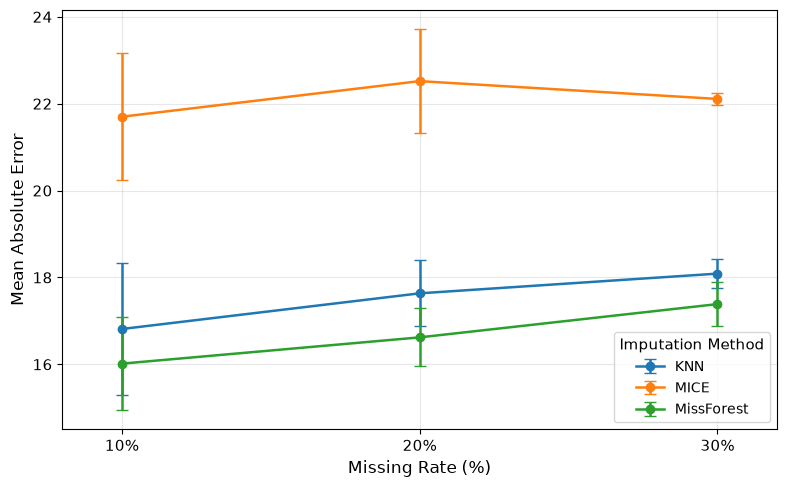

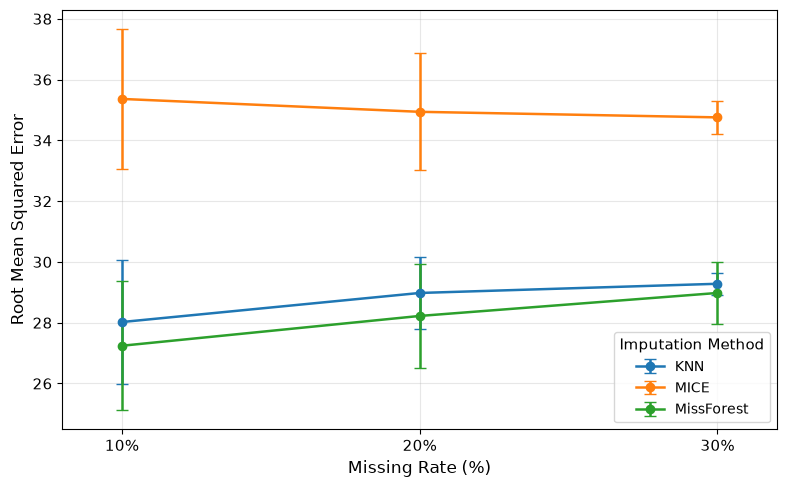

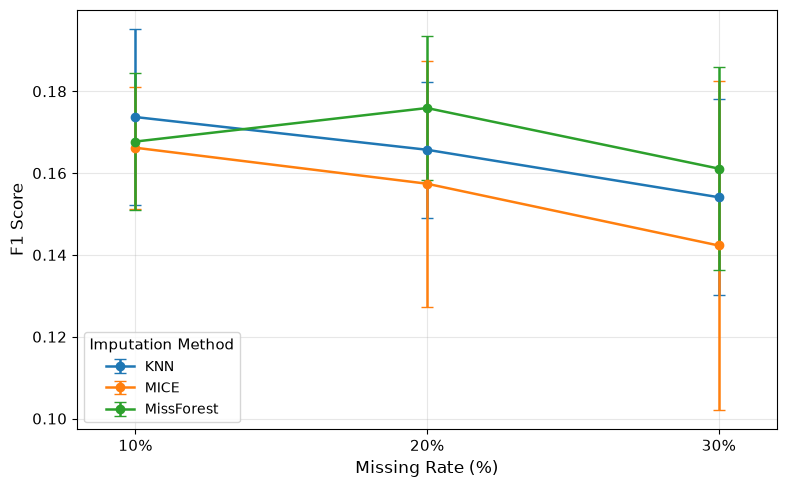

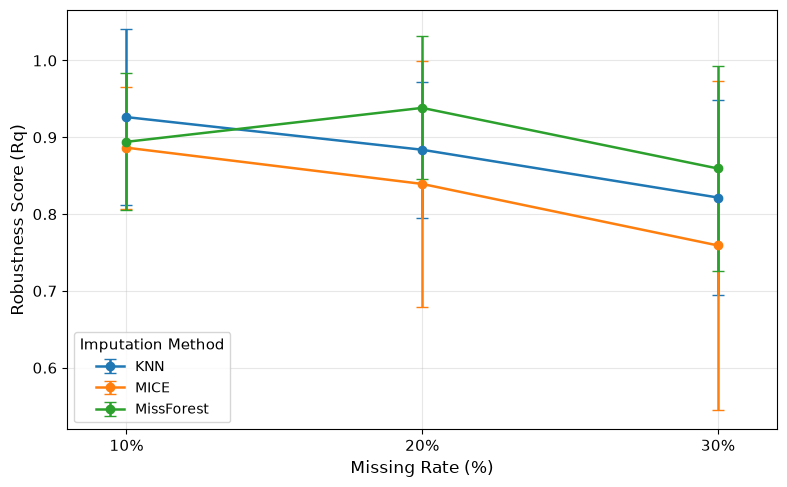

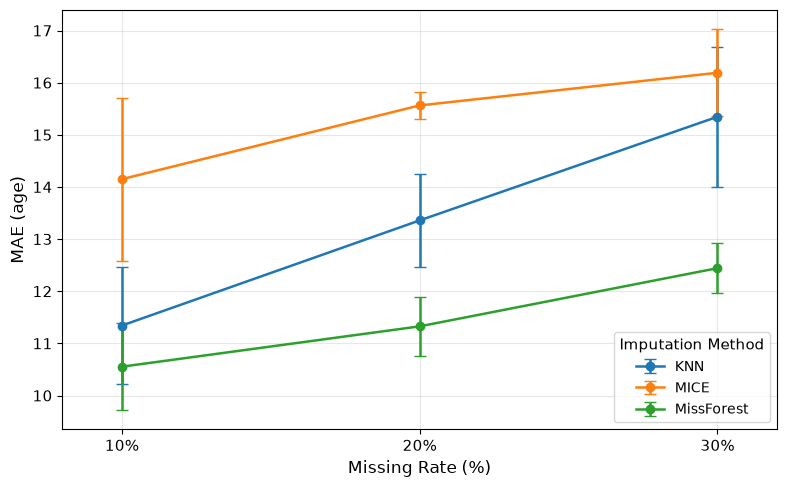

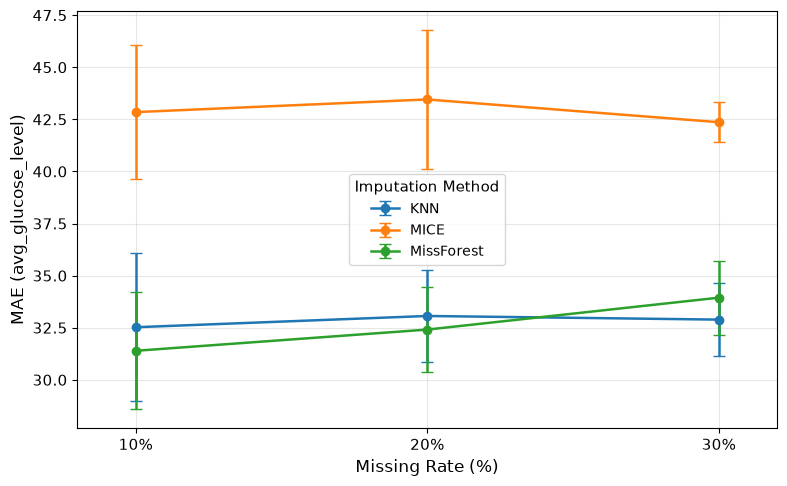

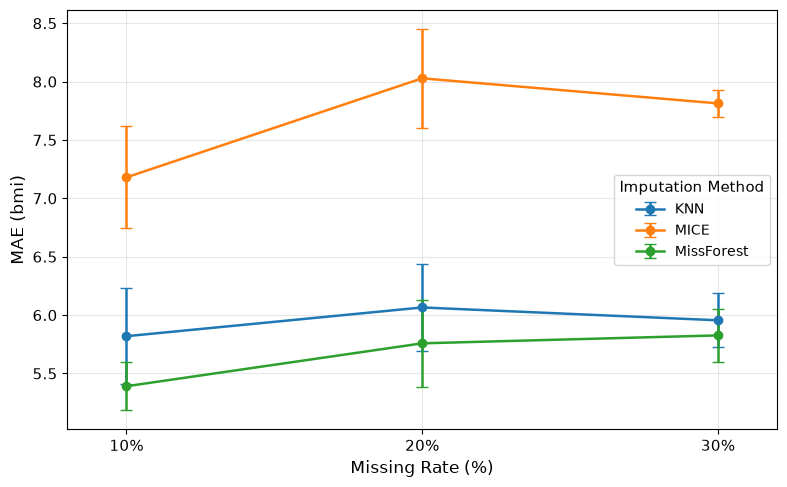

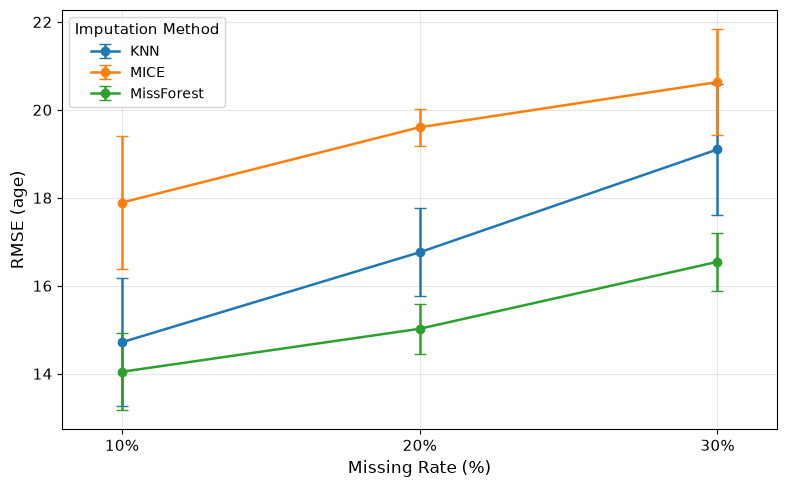

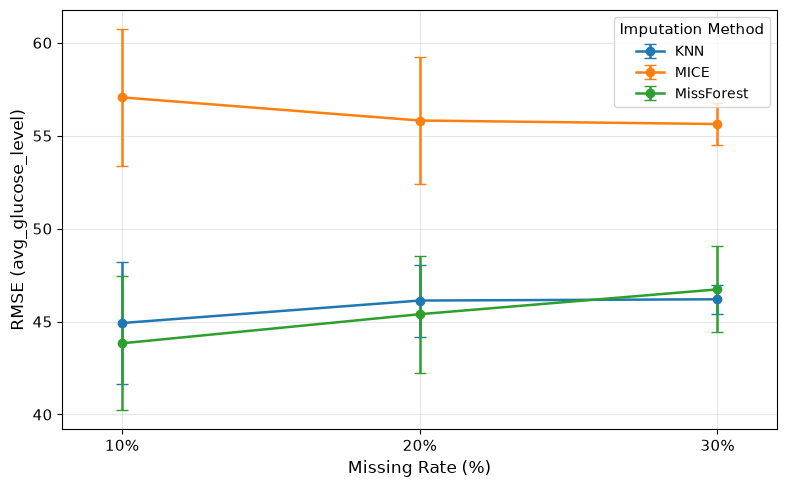

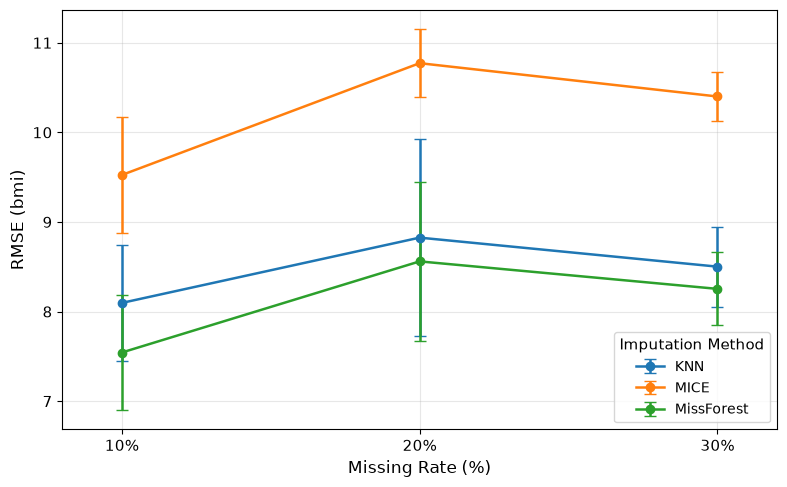


All results and figures saved in: results


In [18]:
# Results: Evaluation Across Five Missing Data Seeds

MISSING_SEEDS = [42, 123, 202, 456, 789]
MISSING_RATES = [0.10, 0.20, 0.30]

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

all_results = []
feature_results = []


# Evaluate the three imputation methods
def get_imputers():
    return {
        "KNN": MixedKNNImputer(n_neighbors=5),
        "MICE": MixedMICEImputer(
            max_iter=10,
            random_state=42
        ),
        "MissForest": MixedMissForestImputer(
            max_iter=10,
            n_estimators=100,
            random_state=42
        )
    }


for seed in MISSING_SEEDS:

    print(f"\nRunning missing seed: {seed}")

    # Generate nested missing datasets for this seed
    missing_sets, masks = generate_missing_test_sets(
        X_test,
        rates=MISSING_RATES,
        random_state=seed
    )

    for rate, X_missing in missing_sets.items():

        mask_df = pd.DataFrame(
            masks[rate],
            index=X_test.index,
            columns=X_test.columns
        )

        for method_name, imputer in get_imputers().items():

            print(f"  {rate} - {method_name}")

            X_imputed = imputer.fit_transform(
                X_missing.copy()
            )

            # Validate imputed data
            assert X_imputed.shape == X_test.shape
            assert X_imputed.columns.equals(X_test.columns)
            assert X_imputed.index.equals(X_test.index)
            assert not X_imputed.isna().any().any()

            # Calculate MAE and RMSE on missing
            # numerical positions only
            numeric_mask = mask_df[NUM_COLS].to_numpy()

            true_values = X_test[NUM_COLS].to_numpy()
            imputed_values = X_imputed[NUM_COLS].to_numpy()

            if numeric_mask.sum() > 0:
                mae = mean_absolute_error(
                    true_values[numeric_mask],
                    imputed_values[numeric_mask]
                )

                rmse = root_mean_squared_error(
                    true_values[numeric_mask],
                    imputed_values[numeric_mask]
                )
            else:
                mae = np.nan
                rmse = np.nan

            # Calculate feature-level errors
            for col in NUM_COLS:

                col_mask = mask_df[col]

                if col_mask.sum() == 0:
                    continue

                feature_mae = mean_absolute_error(
                    X_test.loc[col_mask, col],
                    X_imputed.loc[col_mask, col]
                )

                feature_rmse = root_mean_squared_error(
                    X_test.loc[col_mask, col],
                    X_imputed.loc[col_mask, col]
                )

                feature_results.append({
                    "Seed": seed,
                    "Missing Rate": rate,
                    "Method": method_name,
                    "Feature": col,
                    "MAE": feature_mae,
                    "RMSE": feature_rmse
                })

            # Evaluate downstream classification
            y_pred = baseline_rf.predict(X_imputed)

            f1 = f1_score(
                y_test,
                y_pred,
                zero_division=0
            )

            rq = (
                f1 / f1_baseline
                if f1_baseline > 0
                else np.nan
            )

            all_results.append({
                "Seed": seed,
                "Missing Rate": rate,
                "Method": method_name,
                "MAE": mae,
                "RMSE": rmse,
                "F1": f1,
                "Rq": rq
            })


# Save Individual Experimental Results

df_results = pd.DataFrame(all_results)

df_results.to_csv(
    OUTPUT_DIR / "individual_results.csv",
    index=False
)


# Save Individual and Summary Results for Each Method

method_names = ["KNN", "MICE", "MissForest"]
metrics = ["MAE", "RMSE", "F1", "Rq"]

for method_name in method_names:

    # Select the results for the current imputation method
    method_results = df_results[
        df_results["Method"] == method_name
    ].copy()

    # Keep the columns in a consistent order
    method_results = method_results[
        ["Seed", "Missing Rate", "MAE", "RMSE", "F1", "Rq"]
    ]

    # Sort by missing rate and seed
    method_results = method_results.sort_values(
        by=["Missing Rate", "Seed"]
    )

    # Save all 15 individual experimental results
    method_results.to_csv(
        OUTPUT_DIR / f"{method_name}_individual_results.csv",
        index=False
    )

    # Calculate mean and standard deviation across five seeds
    method_summary = (
        method_results
        .groupby("Missing Rate")[metrics]
        .agg(["mean", "std"])
        .reset_index()
    )

    method_summary.columns = [
        "Missing Rate",
        "MAE Mean",
        "MAE Std",
        "RMSE Mean",
        "RMSE Std",
        "F1 Mean",
        "F1 Std",
        "Rq Mean",
        "Rq Std"
    ]

    method_summary = method_summary.round(4)

    method_summary.to_csv(
        OUTPUT_DIR / f"{method_name}_summary_results.csv",
        index=False
    )

    # Display the results
    print(f"\n--- {method_name}: Individual Results ---")
    print(method_results.round(4).to_string(index=False))

    print(f"\n--- {method_name}: Mean and Std Across Five Seeds ---")
    print(method_summary.to_string(index=False))


# Calculate Mean and Standard Deviation Across Five Seeds

df_summary = (
    df_results
    .groupby(["Missing Rate", "Method"])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

df_summary.columns = [
    "Missing Rate",
    "Method",
    "MAE Mean",
    "MAE Std",
    "RMSE Mean",
    "RMSE Std",
    "F1 Mean",
    "F1 Std",
    "Rq Mean",
    "Rq Std"
]

df_summary = df_summary.round(4)

df_summary.to_csv(
    OUTPUT_DIR / "summary_results.csv",
    index=False
)

print("\n--- Mean Results Across Five Missing Seeds ---")
print(df_summary.to_string(index=False))


# Save Feature-Level Results

df_feature_results = pd.DataFrame(feature_results)

df_feature_results.to_csv(
    OUTPUT_DIR / "feature_results.csv",
    index=False
)


# Feature-Level Summary

df_feature_summary = (
    df_feature_results
    .groupby(
        ["Missing Rate", "Method", "Feature"]
    )[["MAE", "RMSE"]]
    .agg(["mean", "std"])
    .reset_index()
)

df_feature_summary.columns = [
    "Missing Rate",
    "Method",
    "Feature",
    "MAE Mean",
    "MAE Std",
    "RMSE Mean",
    "RMSE Std"
]

df_feature_summary = df_feature_summary.round(4)

df_feature_summary.to_csv(
    OUTPUT_DIR / "feature_summary.csv",
    index=False
)


# Generate Publication-Ready Figures

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 100
})

method_order = ["KNN", "MICE", "MissForest"]

metric_labels = {
    "MAE": "Mean Absolute Error",
    "RMSE": "Root Mean Squared Error",
    "F1": "F1 Score",
    "Rq": "Robustness Score (Rq)"
}

x_positions = [0, 1, 2]
x_labels = ["10%", "20%", "30%"]


# Generate Overall Comparison Figures

for metric in metrics:

    plt.figure(figsize=(8, 5))

    for method in method_order:

        method_data = df_summary[
            df_summary["Method"] == method
        ].sort_values("Missing Rate")

        plt.errorbar(
            x_positions,
            method_data[f"{metric} Mean"],
            yerr=method_data[f"{metric} Std"],
            marker="o",
            linestyle="-",
            capsize=4,
            linewidth=1.8,
            label=method
        )

    plt.xlabel("Missing Rate (%)")
    plt.ylabel(metric_labels[metric])

    plt.xticks(
        x_positions,
        x_labels
    )

    plt.xlim(-0.2, 2.2)
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Imputation Method",
        frameon=True
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"{metric}_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# Generate Feature-Level MAE and RMSE Figures

for metric in ["MAE", "RMSE"]:

    for feature in NUM_COLS:

        plt.figure(figsize=(8, 5))

        for method in method_order:

            method_data = df_feature_summary[
                (df_feature_summary["Method"] == method) &
                (df_feature_summary["Feature"] == feature)
            ].sort_values("Missing Rate")

            plt.errorbar(
                x_positions,
                method_data[f"{metric} Mean"],
                yerr=method_data[f"{metric} Std"],
                marker="o",
                linestyle="-",
                capsize=4,
                linewidth=1.8,
                label=method
            )

        plt.xlabel("Missing Rate (%)")
        plt.ylabel(f"{metric} ({feature})")

        plt.xticks(
            x_positions,
            x_labels
        )

        plt.xlim(-0.2, 2.2)
        plt.grid(True, alpha=0.3)

        plt.legend(
            title="Imputation Method",
            frameon=True
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR / f"{feature}_{metric}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()


print("\nAll results and figures saved in:", OUTPUT_DIR)